In [6]:
import numpy as np
import sklearn
from sklearn.cluster import KMeans
from sklearn import preprocessing
import matplotlib.pyplot as plt
from astropy.io import ascii

In [5]:
dataset = ascii.read('Summary_table.txt')
dataset

col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15
str11,str12,str12,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,str5,float64
GRB260421C*,GRB260421351,8:25:18.055,294.97,64.15,3.003092,19.2,1.145,8:25:18.055,6.0902e-06,3.4637e-08,-999.0,19.2,True,61151.35090341
GRB260421B,GRB260421176,4:13:21,190.0021,-17.7401,-999.0,17.981,0.68,4:13:21.170,1.1287e-05,8.4423e-08,2.115,18.151,False,61151.1759375
GRB260421A,GRB260421092,2:12:44,198.81,62.94,5.360986,1.344,0.202,2:12:44.197,3.3135e-07,1.7658e-08,-999.0,1.541,True,61151.09217593
GRB260419B,GRB260419326,7:49:47.876,134.3179,-35.76,7.997119,12.032,1.717,7:49:47.876,7.694e-07,1.4007e-08,-999.0,12.032,True,61149.32624856
GRB260419A,GRB260419298,7:09:40,311.9979,-36.2019,3.572227,35.84,2.757,7:09:40.821,1.4308e-05,7.3801e-08,-999.0,36.661,True,61149.29837963
GRB260418B,GRB260418681,16:20:21,34.69,-40.54,4.3716,11.776,2.573,16:20:21.470,2.4506e-06,3.2929e-08,-999.0,12.246,True,61148.68079861
GRB260418A,GRB260418201,4:49:33.859,140.62,29.27,10.038664,1.664,0.462,4:49:33.859,1.4084e-07,9.7473e-09,-999.0,1.664,True,61148.20108633
GRB260417B,GRB260417655,15:43:54.975,264.79,-27.41,4.850126,7.168,1.305,15:43:54.975,1.4745e-06,1.6516e-08,-999.0,7.168,True,61147.6554974
GRB260417A,GRB260417007,0:10:01.102,252.0,-19.8,-999.0,29.184,6.527,0:10:01.102,3.9021e-06,7.844e-08,-999.0,29.184,False,61147.0069572


In [22]:
def take_out_invalid(a, b):
    a_new = []
    b_new = []
    for i in range(len(a)):
        if a[i] != -999 and b[i] != -999:
            a_new.append(a[i])
            b_new.append(b[i])

    return a_new, b_new

In [66]:
t90 = dataset['col7']
flux = dataset['col10']

t90, flux = take_out_invalid(t90, flux)

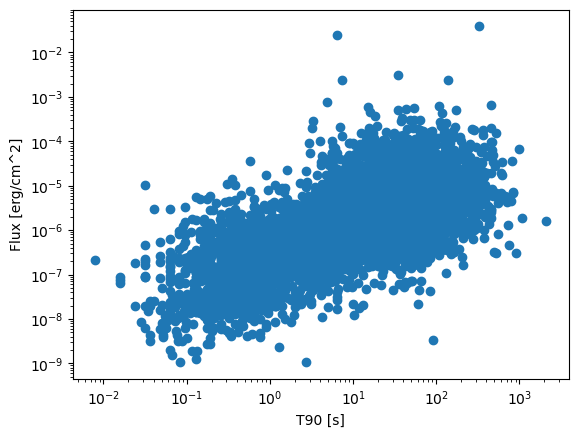

In [67]:
plt.scatter(t90, flux)
plt.xlabel('T90 [s]')
plt.ylabel('Flux [erg/cm^2]')
plt.xscale('log')
plt.yscale('log')

In [68]:
X = np.array([t90, flux])
X = np.reshape(X, (len(t90), 2))
# X.shape

clf = KMeans(n_clusters=2,n_init='auto')
clf.fit(X)

centers = clf.cluster_centers_ 
labels = clf.predict(X)

In [69]:
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(7808,), dtype=int32)

In [70]:
def plot_results(feat1, feat2, lbls):
    feat1 = np.array(feat1)
    feat2 = np.array(feat2)
    
    group0_x = feat1[lbls==0]
    group0_y = feat2[lbls==0]

    group1_x = feat1[lbls==1]
    group1_y = feat2[lbls==1]

    fig, ax = plt.subplots()
    plt.scatter(group0_x, group0_y, color='blue', label='Group 0', alpha=0.5)
    plt.scatter(group1_x, group1_y, color='orange', label='Group 1', alpha=0.3)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()

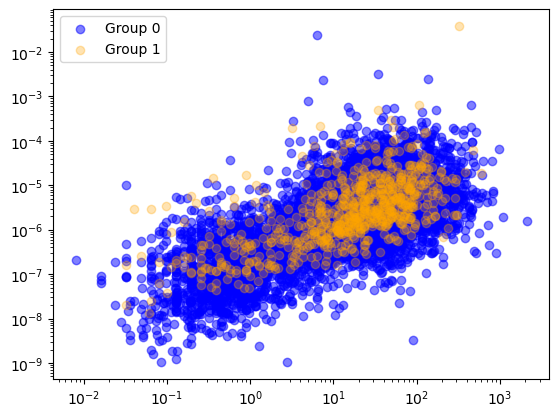

In [71]:
plot_results(t90, flux, labels)